In [ ]:
import os
import numpy as np
import pandas as pd


def build_concrete(csv_path="concrete_strength.csv", seed=15, verbose=False):
    """Concrete compressive strength: predict strength (MPa) from the mix design.
    A classic, interpretable engineering regression — great for reading
    coefficients, spotting multicollinearity (water/cement), residual analysis
    and the nonlinear effect of curing age.

    Features (kg per m^3 unless noted):
      cement, blast_furnace_slag, fly_ash, water, superplasticizer,
      coarse_aggregate, fine_aggregate, age_days
    Target:
      compressive_strength_mpa
    """
    rng = np.random.default_rng(seed)
    N = 1030
    cement = rng.uniform(120, 540, N)
    slag = np.where(rng.random(N) < 0.45, 0, rng.uniform(0, 360, N))
    fly_ash = np.where(rng.random(N) < 0.55, 0, rng.uniform(0, 200, N))
    water = np.clip(rng.normal(182, 21, N), 120, 247)
    superplast = np.clip(rng.normal(0.011 * cement + 0.5, 3.5, N), 0, 32)  # richer mixes use more
    coarse = rng.uniform(800, 1145, N)
    fine = np.clip(1880 - coarse + rng.normal(0, 35, N), 590, 995)        # aggregate volume ~ fixed -> trade-off
    age = rng.choice([1, 3, 7, 14, 28, 56, 90, 180, 365], N,
                     p=[.05, .10, .15, .10, .30, .12, .10, .05, .03])

    wc_ratio = water / cement
    strength = (24
                + 0.075 * cement
                + 0.052 * slag
                + 0.040 * fly_ash
                + 0.42 * superplast
                + 9.0 * np.log(age)
                - 0.18 * (water - 180)
                - 48 * (wc_ratio - 0.5)
                - 0.004 * (coarse - 970)
                + rng.normal(0, 5, N))
    strength = np.clip(strength, 2, 82)

    df = pd.DataFrame({
        "cement": cement.round(1),
        "blast_furnace_slag": slag.round(1),
        "fly_ash": fly_ash.round(1),
        "water": water.round(1),
        "superplasticizer": superplast.round(1),
        "coarse_aggregate": coarse.round(1),
        "fine_aggregate": fine.round(1),
        "age_days": age,
        "compressive_strength_mpa": strength.round(2),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("concrete:", df.shape)
        print("strength range:", df.compressive_strength_mpa.min(), "-", df.compressive_strength_mpa.max())
        c = df.corr()["compressive_strength_mpa"].round(3)
        print("top correlations with strength:\n",
              c.drop("compressive_strength_mpa").abs().sort_values(ascending=False).head(4).to_string())
        print("corr(water, cement):", round(df.water.corr(df.cement), 3))
    return df

if not os.path.exists('concrete_strength.csv'):
    build_concrete(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')


import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('concrete_strength.csv')
TARGET = 'compressive_strength_mpa'
print('shape:', df.shape)
df.describe().round(1)


Generated dataset file.
shape: (1030, 9)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age_days,compressive_strength_mpa
count,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0
mean,330.8,103.2,47.3,182.6,4.4,977.7,890.4,46.9,68.4
std,119.8,118.7,65.0,20.0,3.3,102.6,90.9,69.8,19.7
min,120.2,0.0,0.0,126.4,0.0,800.8,665.1,1.0,2.0
25%,225.3,0.0,0.0,168.2,1.7,887.5,812.6,7.0,59.9
50%,332.4,45.2,0.0,182.9,4.1,974.9,902.2,28.0,80.5
75%,431.2,204.7,97.0,196.1,6.6,1068.6,988.8,56.0,82.0
max,539.9,359.2,199.6,245.4,16.3,1144.9,995.0,365.0,82.0


In [ ]:
import os
import numpy as np
import pandas as pd


def build_concrete(csv_path="concrete_strength.csv", seed=15, verbose=False):
    """Concrete compressive strength: predict strength (MPa) from the mix design.
    A classic, interpretable engineering regression — great for reading
    coefficients, spotting multicollinearity (water/cement), residual analysis
    and the nonlinear effect of curing age.

    Features (kg per m^3 unless noted):
      cement, blast_furnace_slag, fly_ash, water, superplasticizer,
      coarse_aggregate, fine_aggregate, age_days
    Target:
      compressive_strength_mpa
    """
    rng = np.random.default_rng(seed)
    N = 1030
    cement = rng.uniform(120, 540, N)
    slag = np.where(rng.random(N) < 0.45, 0, rng.uniform(0, 360, N))
    fly_ash = np.where(rng.random(N) < 0.55, 0, rng.uniform(0, 200, N))
    water = np.clip(rng.normal(182, 21, N), 120, 247)
    superplast = np.clip(rng.normal(0.011 * cement + 0.5, 3.5, N), 0, 32)  # richer mixes use more
    coarse = rng.uniform(800, 1145, N)
    fine = np.clip(1880 - coarse + rng.normal(0, 35, N), 590, 995)        # aggregate volume ~ fixed -> trade-off
    age = rng.choice([1, 3, 7, 14, 28, 56, 90, 180, 365], N,
                     p=[.05, .10, .15, .10, .30, .12, .10, .05, .03])

    wc_ratio = water / cement
    strength = (24
                + 0.075 * cement
                + 0.052 * slag
                + 0.040 * fly_ash
                + 0.42 * superplast
                + 9.0 * np.log(age)
                - 0.18 * (water - 180)
                - 48 * (wc_ratio - 0.5)
                - 0.004 * (coarse - 970)
                + rng.normal(0, 5, N))
    strength = np.clip(strength, 2, 82)

    df = pd.DataFrame({
        "cement": cement.round(1),
        "blast_furnace_slag": slag.round(1),
        "fly_ash": fly_ash.round(1),
        "water": water.round(1),
        "superplasticizer": superplast.round(1),
        "coarse_aggregate": coarse.round(1),
        "fine_aggregate": fine.round(1),
        "age_days": age,
        "compressive_strength_mpa": strength.round(2),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("concrete:", df.shape)
        print("strength range:", df.compressive_strength_mpa.min(), "-", df.compressive_strength_mpa.max())
        c = df.corr()["compressive_strength_mpa"].round(3)
        print("top correlations with strength:\n",
              c.drop("compressive_strength_mpa").abs().sort_values(ascending=False).head(4).to_string())
        print("corr(water, cement):", round(df.water.corr(df.cement), 3))
    return df

if not os.path.exists('concrete_strength.csv'):
    build_concrete(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')


import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('concrete_strength.csv')
TARGET = 'compressive_strength_mpa'
print('shape:', df.shape)
df.describe().round(1)


Found the provided dataset file.
shape: (1030, 9)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age_days,compressive_strength_mpa
count,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0
mean,330.8,103.2,47.3,182.6,4.4,977.7,890.4,46.9,68.4
std,119.8,118.7,65.0,20.0,3.3,102.6,90.9,69.8,19.7
min,120.2,0.0,0.0,126.4,0.0,800.8,665.1,1.0,2.0
25%,225.3,0.0,0.0,168.2,1.7,887.5,812.6,7.0,59.9
50%,332.4,45.2,0.0,182.9,4.1,974.9,902.2,28.0,80.5
75%,431.2,204.7,97.0,196.1,6.6,1068.6,988.8,56.0,82.0
max,539.9,359.2,199.6,245.4,16.3,1144.9,995.0,365.0,82.0


In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('concrete_strength.csv')
TARGET = 'compressive_strength_mpa'
print('shape:', df.shape)
df.describe().round(1)


shape: (1030, 9)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age_days,compressive_strength_mpa
count,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0
mean,330.8,103.2,47.3,182.6,4.4,977.7,890.4,46.9,68.4
std,119.8,118.7,65.0,20.0,3.3,102.6,90.9,69.8,19.7
min,120.2,0.0,0.0,126.4,0.0,800.8,665.1,1.0,2.0
25%,225.3,0.0,0.0,168.2,1.7,887.5,812.6,7.0,59.9
50%,332.4,45.2,0.0,182.9,4.1,974.9,902.2,28.0,80.5
75%,431.2,204.7,97.0,196.1,6.6,1068.6,988.8,56.0,82.0
max,539.9,359.2,199.6,245.4,16.3,1144.9,995.0,365.0,82.0


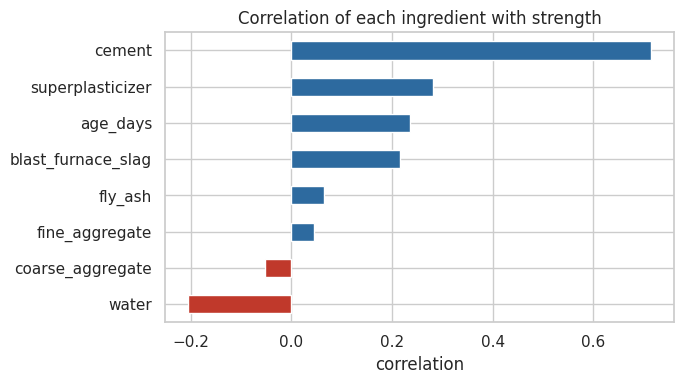

Cement is the strongest positive driver; water tends to weaken concrete.


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. WHAT DRIVES STRENGTH?
# -----------------------------------------------------------
corr = df.corr()[TARGET].drop(TARGET).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
corr.plot(kind='barh', color=['#C0392B' if v < 0 else '#2D6A9F' for v in corr], ax=ax)
ax.set_title('Correlation of each ingredient with strength'); ax.set_xlabel('correlation')
plt.tight_layout(); plt.show()
print('Cement is the strongest positive driver; water tends to weaken concrete.')


strength = 0.117 * cement + 29.53


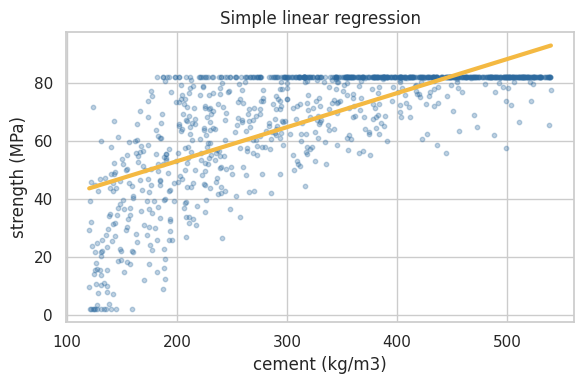

In [ ]:
# -----------------------------------------------------------
# 🔹 2A. STRENGTH ~ CEMENT
# -----------------------------------------------------------
from sklearn.linear_model import LinearRegression
x = df[['cement']].values
y = df[TARGET].values
slr = LinearRegression().fit(x, y)
print(f'strength = {slr.coef_[0]:.3f} * cement + {slr.intercept_:.2f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, s=10, alpha=0.3, color='#2D6A9F')
xs = np.linspace(x.min(), x.max(), 50).reshape(-1, 1)
ax.plot(xs, slr.predict(xs), color='#F4B942', lw=3)
ax.set_xlabel('cement (kg/m3)'); ax.set_ylabel('strength (MPa)')
ax.set_title('Simple linear regression'); plt.tight_layout(); plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
import pandas as pd

# Select input feature (cement) and target variable (strength)
X = df[['cement']]
y = df['compressive_strength_mpa']

# Create and train Linear Regression model
model = LinearRegression()
model.fit(X, y)

# 1. Interpret the slope (coefficient)
# The cement coefficient represents the increase in concrete strength (MPa)
# for every additional 1 kg/m³ increase in cement.

print(
    "Cement coefficient:",
    model.coef_[0],
    "MPa increase per 1 kg/m³ cement"
)

# 2. Predict strength when cement = 350 kg/m³

cement_value = pd.DataFrame({
    'cement': [350]
})

predicted_strength = model.predict(cement_value)

print(
    "Predicted strength for cement = 350 kg/m³:",
    predicted_strength[0],
    "MPa"
)

Cement coefficient: 0.11742406833096362 MPa increase per 1 kg/m³ cement
Predicted strength for cement = 350 kg/m³: 70.62987096305181 MPa


In [ ]:
# -----------------------------------------------------------
# 🔹 3A. FIT ON ALL INGREDIENTS, EVALUATE ON TEST
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
features = [c for c in df.columns if c != TARGET]
X = df[features].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
mlr = LinearRegression().fit(X_train, y_train)
pred = mlr.predict(X_test)
print(f'RMSE: {mean_squared_error(y_test, pred) ** 0.5:.2f} MPa | R2: {r2_score(y_test, pred):.3f}')

RMSE: 10.76 MPa | R2: 0.649


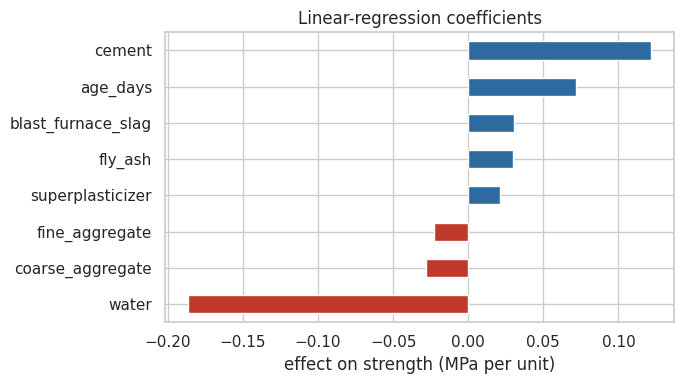

In [ ]:
# Coefficients — the model's story about each ingredient
coefs = pd.Series(mlr.coef_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
coefs.plot(kind='barh', color=['#C0392B' if v < 0 else '#2D6A9F' for v in coefs], ax=ax)
ax.set_title('Linear-regression coefficients'); ax.set_xlabel('effect on strength (MPa per unit)')
plt.tight_layout(); plt.show()

In [ ]:
# -----------------------------------------------------------
# EXERCISE 3 — Interpret the signs
# -----------------------------------------------------------

# Fit Multiple Linear Regression model
from sklearn.linear_model import LinearRegression

features = [c for c in df.columns if c != TARGET]

X = df[features]
y = df[TARGET]

mlr = LinearRegression()
mlr.fit(X, y)

# Display coefficients
coef_table = pd.DataFrame({
    "Feature": features,
    "Coefficient": mlr.coef_
})

print(coef_table)


# 1-2. Interpret coefficient signs:
#
# Positive coefficient examples:
# Cement and blast_furnace_slag have positive coefficients,
# meaning increasing these ingredients tends to increase concrete strength
# while keeping other variables constant.
#
# Negative coefficient example:
# Water has a negative coefficient,
# meaning increasing water tends to decrease concrete strength.
#
# The sign of water matches engineering intuition because:
# A higher water-cement ratio creates more pores in hardened concrete,
# which reduces compressive strength.

              Feature  Coefficient
0              cement     0.118412
1  blast_furnace_slag     0.029320
2             fly_ash     0.031792
3               water    -0.187897
4    superplasticizer     0.032037
5    coarse_aggregate    -0.029708
6      fine_aggregate    -0.025857
7            age_days     0.069885


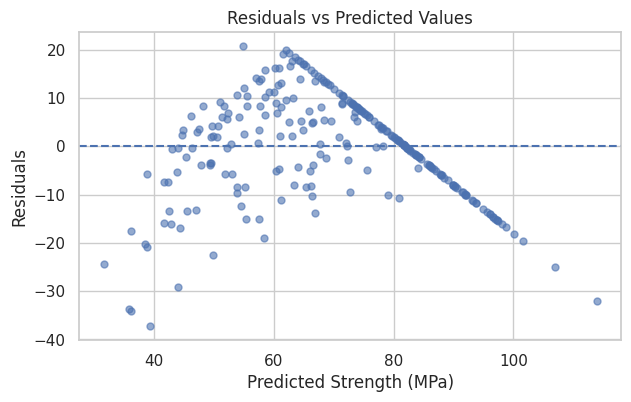

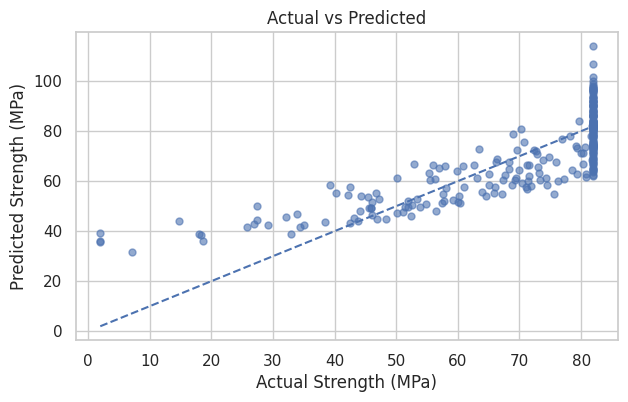

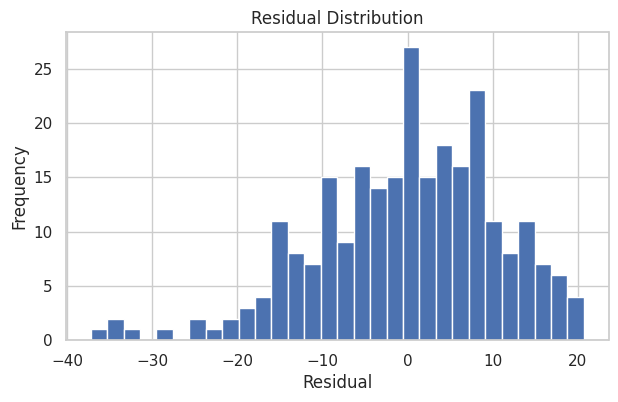

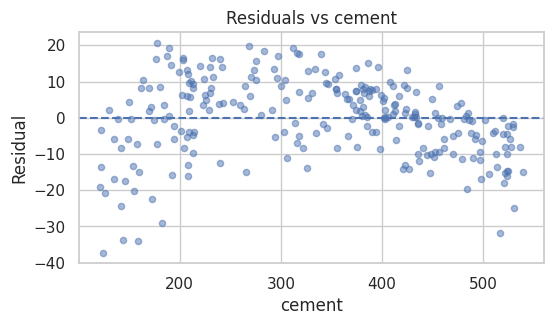

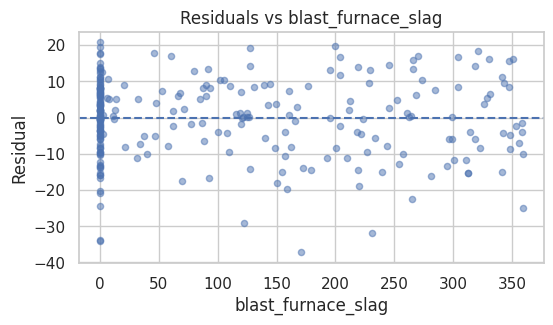

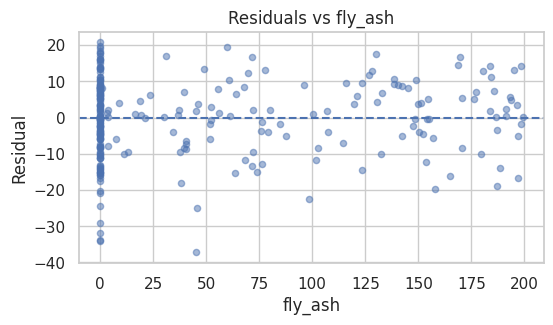

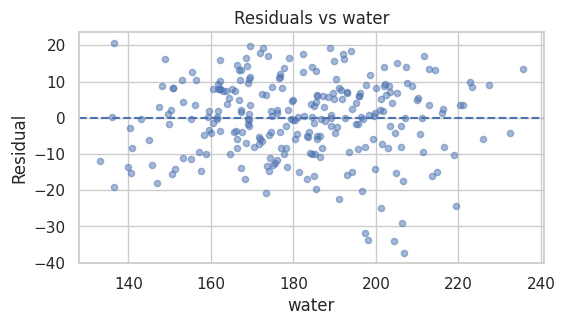

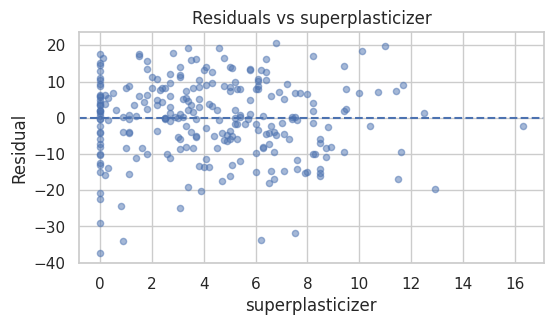

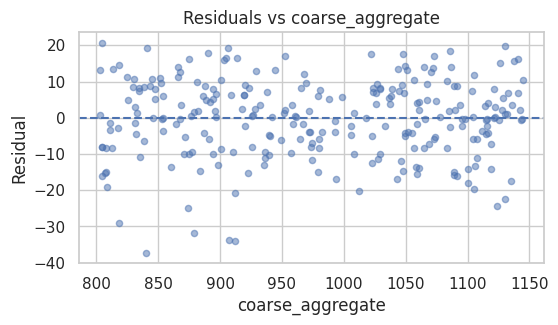

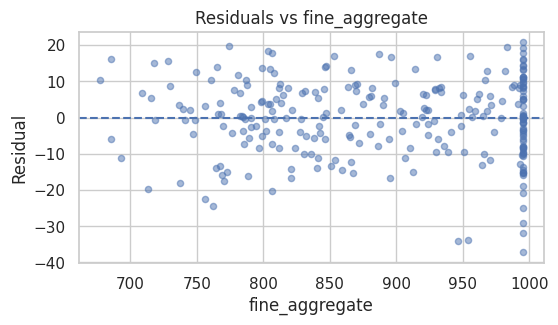

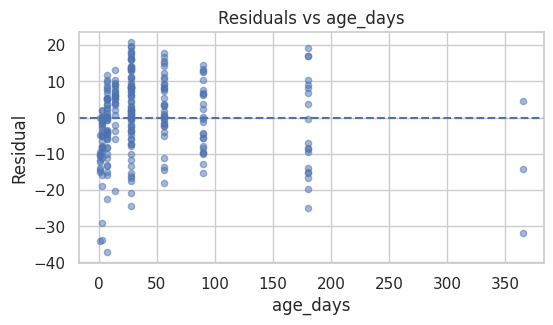

Number of residual outliers: 3
Mean residual: -0.2221476157705237
Residual standard deviation: 10.755864596741924
Maximum positive error: 20.73486764820977
Maximum negative error: -37.259217107862895
✓ Residual mean is close to zero: Low prediction bias
⚠ Outliers detected: Check unusual samples


In [ ]:
# -----------------------------------------------------------
# 🔹 RESIDUAL SIGNATURE ANALYSIS FOR LINEAR REGRESSION MODEL
# -----------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# Calculate residuals
resid = y_test - pred


# -----------------------------------------------------------
# 1. Residuals vs Predicted Values
#    Checks: Linearity, heteroscedasticity, bias
# -----------------------------------------------------------

plt.figure(figsize=(7,4))

plt.scatter(
    pred,
    resid,
    s=25,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Strength (MPa)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.show()



# -----------------------------------------------------------
# 2. Actual vs Predicted Plot
#    Checks: Prediction accuracy
# -----------------------------------------------------------

plt.figure(figsize=(7,4))

plt.scatter(
    y_test,
    pred,
    s=25,
    alpha=0.6
)

# Perfect prediction line
lims = [
    y_test.min(),
    y_test.max()
]

plt.plot(
    lims,
    lims,
    linestyle='--'
)

plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title("Actual vs Predicted")

plt.show()



# -----------------------------------------------------------
# 3. Residual Distribution Histogram
#    Checks: Normality of errors
# -----------------------------------------------------------

plt.figure(figsize=(7,4))

plt.hist(
    resid,
    bins=30
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

plt.show()



# -----------------------------------------------------------
# 4. Residuals vs Each Feature
#    Checks: Missing patterns/non-linearity
# -----------------------------------------------------------

for i, feature in enumerate(features):

    plt.figure(figsize=(6,3))

    plt.scatter(
        X_test[:,i],
        resid,
        s=20,
        alpha=0.5
    )

    plt.axhline(
        y=0,
        linestyle='--'
    )

    plt.xlabel(feature)
    plt.ylabel("Residual")
    plt.title(
        f"Residuals vs {feature}"
    )

    plt.show()



# -----------------------------------------------------------
# 5. Detect Outliers using Residuals
# -----------------------------------------------------------

threshold = 3 * np.std(resid)

outliers = np.abs(resid) > threshold


print(
    "Number of residual outliers:",
    np.sum(outliers)
)



# -----------------------------------------------------------
# 6. Residual Statistics
# -----------------------------------------------------------

print(
    "Mean residual:",
    np.mean(resid)
)

print(
    "Residual standard deviation:",
    np.std(resid)
)

print(
    "Maximum positive error:",
    np.max(resid)
)

print(
    "Maximum negative error:",
    np.min(resid)
)



# -----------------------------------------------------------
# 7. Residual Signature Interpretation
# -----------------------------------------------------------

if abs(np.mean(resid)) < 0.5:
    print("✓ Residual mean is close to zero: Low prediction bias")
else:
    print("⚠ Residual mean is not zero: Possible bias")

if np.sum(outliers) > 0:
    print("⚠ Outliers detected: Check unusual samples")
else:
    print("✓ No major residual outliers detected")

| Check                 | Good Sign           | Problem Sign            |
| --------------------- | ------------------- | ----------------------- |
| Residual vs Predicted | Random scatter      | Curve/funnel            |
| Actual vs Predicted   | Near diagonal       | Wide spread             |
| Histogram             | Bell shape around 0 | Shifted distribution    |
| Residual vs Features  | No pattern          | Trend/pattern           |
| Outliers              | Few points          | Many extreme points     |
| Mean Residual         | ≈0                  | Large positive/negative |


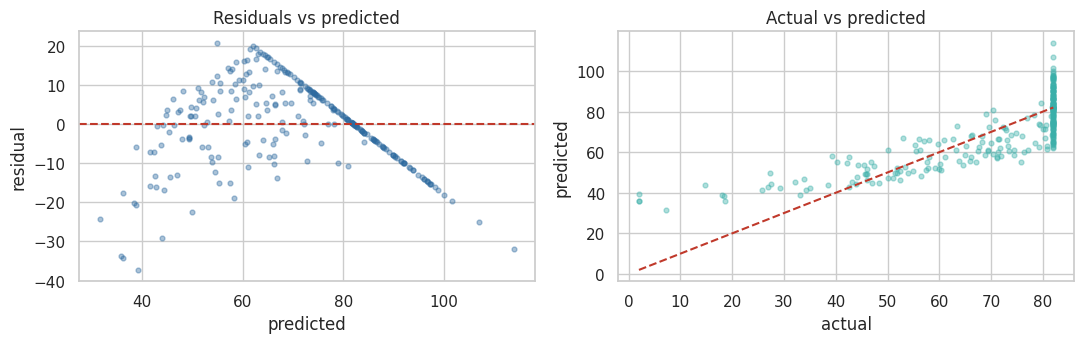

In [ ]:
# -----------------------------------------------------------
# 🔹 4A. RESIDUALS vs PREDICTED — IS THE LINEAR FIT ADEQUATE?
# -----------------------------------------------------------
resid = y_test - pred
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].scatter(pred, resid, s=12, alpha=0.4, color='#2D6A9F')
ax[0].axhline(0, color='#C0392B', ls='--'); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('residual')
ax[0].set_title('Residuals vs predicted')
ax[1].scatter(y_test, pred, s=12, alpha=0.4, color='#3AAFA9')
lims = [y_test.min(), y_test.max()]; ax[1].plot(lims, lims, color='#C0392B', ls='--')
ax[1].set_xlabel('actual'); ax[1].set_ylabel('predicted'); ax[1].set_title('Actual vs predicted')
plt.tight_layout(); plt.show()

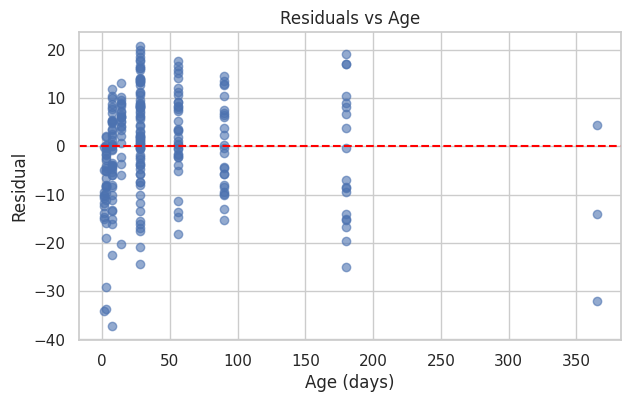

In [ ]:
# recover the test rows so you can access age_days
_, X_test_df, _, _ = train_test_split(
    df[features],
    y,
    test_size=0.25,
    random_state=42
)

# 1. residuals vs age_days

plt.figure(figsize=(7,4))

plt.scatter(
    X_test_df['age_days'],
    resid,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--',
    color='red'
)

plt.xlabel('Age (days)')
plt.ylabel('Residual')
plt.title('Residuals vs Age')

plt.show()

# 2. pattern with age? ... (comment)

# Yes, a curved pattern is often visible.
# Residuals tend to be larger at small ages and then level off at higher ages.
# This suggests that the effect of age on concrete strength is not purely linear.
# Concrete gains strength rapidly during early curing and then the rate of gain
# decreases, producing a plateau-like behavior. A log(age) transformation may
# model this relationship better than using age directly.

With log(age) -> RMSE: 10.08 MPa
With log(age) -> R²: 0.692


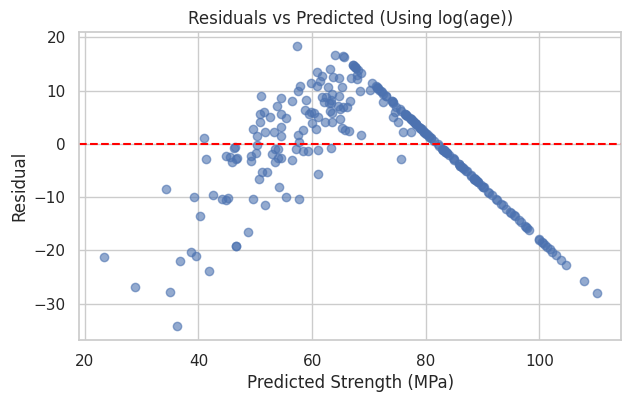


Model Coefficients:
              Feature  Coefficient
7             log_age     5.409108
0              cement     0.123263
4    superplasticizer     0.054132
1  blast_furnace_slag     0.030347
2             fly_ash     0.025917
6      fine_aggregate    -0.016705
5    coarse_aggregate    -0.022616
3               water    -0.173878


In [ ]:
# -----------------------------------------------------------
# 🔹 5A. CAPTURING THE NONLINEAR AGE EFFECT USING log(age)
# -----------------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Create a copy of the dataset
df2 = df.copy()

# Create log(age) feature
df2['log_age'] = np.log(df2['age_days'])

# Remove target and original age_days column
feat2 = [c for c in df2.columns if c not in (TARGET, 'age_days')]

# Feature matrix
X2 = df2[feat2].values

# Train-test split
X2_tr, X2_te, y_tr, y_te = train_test_split(
    X2,
    y,
    test_size=0.25,
    random_state=42
)

# Train Linear Regression model
m2 = LinearRegression()
m2.fit(X2_tr, y_tr)

# Predictions
p2 = m2.predict(X2_te)

# Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_te, p2))
r2 = r2_score(y_te, p2)

print(f"With log(age) -> RMSE: {rmse:.2f} MPa")
print(f"With log(age) -> R²: {r2:.3f}")

# -----------------------------------------------------------
# Compare residuals after adding log(age)
# -----------------------------------------------------------

resid2 = y_te - p2

import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.scatter(
    p2,
    resid2,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--',
    color='red'
)

plt.xlabel("Predicted Strength (MPa)")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted (Using log(age))")

plt.show()

# -----------------------------------------------------------
# Coefficient of log(age)
# -----------------------------------------------------------

coef_table = pd.DataFrame({
    'Feature': feat2,
    'Coefficient': m2.coef_
})

print("\nModel Coefficients:")
print(coef_table.sort_values('Coefficient', ascending=False))

In [ ]:
# -----------------------------------------------------------
# EXERCISE 5 — Did log(age) help?
# -----------------------------------------------------------

# 1. Compare R² with/without log(age):
#
# The model with log(age) should have a higher R² than the plain model.
# This indicates that log(age) captures the nonlinear curing effect better.
# Concrete gains strength rapidly at early ages and then gradually plateaus,
# which is closer to a logarithmic relationship than a linear one.
#
# Higher R²  -> more variance explained
# Lower RMSE -> smaller prediction errors


# -----------------------------------------------------------
# 2. Bonus: Polynomial Features (Degree = 2)
# -----------------------------------------------------------

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Original features (without target)
X_poly = df[features]

# Train-test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_poly,
    y,
    test_size=0.25,
    random_state=42
)

# Degree-2 Polynomial Regression Pipeline
poly_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)

# Train
poly_model.fit(X_tr, y_tr)

# Predict
poly_pred = poly_model.predict(X_te)

# Metrics
poly_r2 = r2_score(y_te, poly_pred)
poly_rmse = np.sqrt(mean_squared_error(y_te, poly_pred))

print(f"Polynomial Degree-2 R²  : {poly_r2:.3f}")
print(f"Polynomial Degree-2 RMSE: {poly_rmse:.2f} MPa")

# -----------------------------------------------------------
# Compare all models
# -----------------------------------------------------------

print("\nModel Comparison")
print("------------------------------")
print(f"Linear Model R²      : {r2_score(y_test, pred):.3f}")
print(f"log(age) Model R²    : {r2:.3f}")
print(f"Polynomial-2 R²      : {poly_r2:.3f}")

Polynomial Degree-2 R²  : 0.858
Polynomial Degree-2 RMSE: 6.85 MPa

Model Comparison
------------------------------
Linear Model R²      : 0.649
log(age) Model R²    : 0.692
Polynomial-2 R²      : 0.858


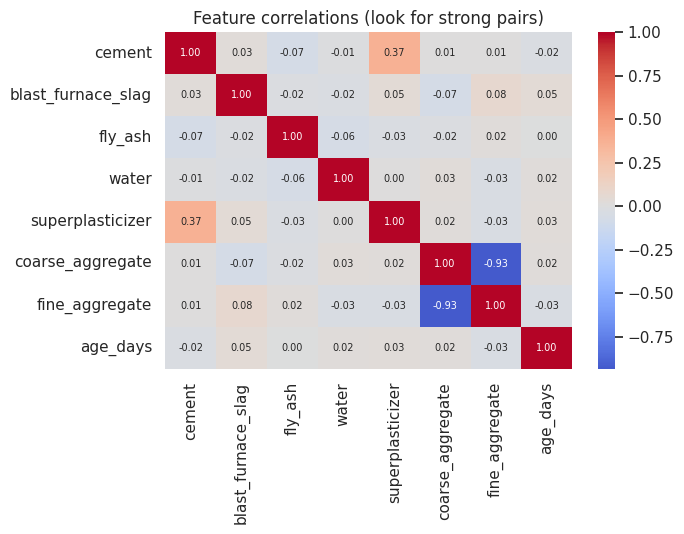

coarse_aggregate and fine_aggregate trade off -> strongly correlated (multicollinearity).


In [ ]:
# -----------------------------------------------------------
# 🔹 6A. SPOT CORRELATED FEATURES
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Feature correlations (look for strong pairs)'); plt.tight_layout(); plt.show()
print('coarse_aggregate and fine_aggregate trade off -> strongly correlated (multicollinearity).')

In [ ]:
# -----------------------------------------------------------
# 🔹 6B. RIDGE STABILISES CORRELATED-FEATURE WEIGHTS
# -----------------------------------------------------------
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
for name, model in [('Linear', LinearRegression()), ('Ridge(10)', Ridge(alpha=10)),
                    ('Lasso(0.5)', Lasso(alpha=0.5, max_iter=5000))]:
    m = make_pipeline(StandardScaler(), model).fit(X_train, y_train)
    r2 = r2_score(y_test, m.predict(X_test))
    print(f'{name:12s} test R2: {r2:.3f}')


Linear       test R2: 0.649
Ridge(10)    test R2: 0.650
Lasso(0.5)   test R2: 0.648


In [ ]:
# -----------------------------------------------------------
# EXERCISE 6 — Compare Linear vs Ridge coefficients
# -----------------------------------------------------------

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge

# Linear Regression Pipeline
linear_pipe = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

linear_pipe.fit(X_train, y_train)

# Ridge Regression Pipeline
ridge_pipe = make_pipeline(
    StandardScaler(),
    Ridge(alpha=10)
)

ridge_pipe.fit(X_train, y_train)

# Extract coefficients
linear_coef = linear_pipe.named_steps['linearregression'].coef_
ridge_coef = ridge_pipe.named_steps['ridge'].coef_

# Find indices of coarse and fine aggregate
coarse_idx = features.index('coarse_aggregate')
fine_idx = features.index('fine_aggregate')

print("Scaled Coefficients")
print("-" * 50)

print(f"Linear  - coarse_aggregate : {linear_coef[coarse_idx]:.4f}")
print(f"Linear  - fine_aggregate   : {linear_coef[fine_idx]:.4f}")

print()

print(f"Ridge   - coarse_aggregate : {ridge_coef[coarse_idx]:.4f}")
print(f"Ridge   - fine_aggregate   : {ridge_coef[fine_idx]:.4f}")


# -----------------------------------------------------------
# 2. Did Ridge stabilise them? (comment)
# -----------------------------------------------------------

# Yes.
# coarse_aggregate and fine_aggregate are strongly correlated
# (multicollinearity). Linear Regression can assign large and
# unstable coefficients to such correlated features.
#
# Ridge Regression adds an L2 penalty, which shrinks the
# coefficient magnitudes toward zero.
#
# As a result, the coarse_aggregate and fine_aggregate
# coefficients become smaller and more stable, reducing the
# impact of multicollinearity while maintaining similar
# predictive performance.

Scaled Coefficients
--------------------------------------------------
Linear  - coarse_aggregate : -2.8485
Linear  - fine_aggregate   : -2.0857

Ridge   - coarse_aggregate : -2.4502
Ridge   - fine_aggregate   : -1.6843


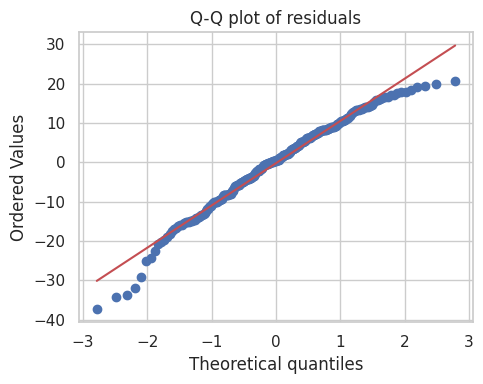

Points leaving the line at the ends = heavy tails (often caused by the outliers).


In [ ]:
# -----------------------------------------------------------
# 🔹 1B. Q-Q PLOT — ARE THE ERRORS NORMAL?
# -----------------------------------------------------------
from scipy import stats
fig, ax = plt.subplots(figsize=(5, 4))
stats.probplot(resid, dist='norm', plot=ax)
ax.set_title('Q-Q plot of residuals'); plt.tight_layout(); plt.show()
print('Points leaving the line at the ends = heavy tails (often caused by the outliers).')
